# **Government Bond Yield Curve Calibration**

Our Work Here will be to calibrate US Treasury Yield Curve and try to fit the curve with avaialable maturities to find Interest rate at remaining maturities.

**Yield Curve Calibration – Nelson-Siegel & Cubic Spline Models**
Python | Yield Curve Modelling | Nelson-Siegel | Differential Evolution | Cubic Spline

* Calibrated the Nelson-Siegel yield curve model using market yield data across various maturities.

* Minimized the model error using a Mean Squared Error (MSE) objective function; achieved MSE ≈ 0.0039 for upward Sloping Structures.

* Applied Differential Evolution optimization to fit Nelson-Siegel parameters, ensuring global convergence.

* Identified limitations of Nelson-Siegel in non-monotonic yield curves; experimented with Cubic Spline interpolation for better local fit.

* Plotted and analyzed market vs model yield curves to evaluate fit accuracy and model behavior.

## US Treasury Yields Data

In [2]:
#fredapi is used to import US treasury yield curve data
!pip install fredapi

In [97]:
import pandas as pd
import numpy as np
from fredapi import Fred
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()


The US Treasury Data will be structured like "Columns will be of time period i.e 1 Month, 3 Months ... and rows will be of every day" since the yields curve (i.e yield for a particular maturity) changes every day. This is because of number of factors but majorly due to demand supply of bonds for a particular yield.

In [8]:
# Initialize the FRED API with your key
fred = Fred(api_key='5079f41d061a4037d81f3da69e018803')

# List of Treasury yield series IDs, the yields are for 1 month, 3 months, 6 months, 1 year, 2 years, 3 years, 5 years.... 30 years
series_ids = ['DGS1MO', 'DGS3MO', 'DGS6MO', 'DGS1', 'DGS2', 'DGS3', 'DGS5',
              'DGS7', 'DGS10', 'DGS20', 'DGS30']

#function to get data for single series or single time Period
def get_series(series_id):
    data = fred.get_series(series_id, observation_start="1975-01-01",observation_end="2025-06-10")
    return data

#Get data for all the Series in form of dictionary 
yields_dict = {series_id: get_series(series_id) for series_id in series_ids}

#converting the dictionary into data frame
yields = pd.DataFrame(yields_dict)

#renaming columns for clarity 
yields.columns = ['1 Month', '3 Month', '6 Month', '1 Year', '2 Year', '3 Year', '5 Year', '7 Year', '10 Year', '20 Year', '30 Year']

yields

,1 Month,3 Month,6 Month,1 Year,2 Year,3 Year,5 Year,7 Year,10 Year,20 Year,30 Year
1975-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1975-01-02,NaN,NaN,NaN,7.27,NaN,7.34,7.34,7.34,7.42,7.94,NaN
1975-01-03,NaN,NaN,NaN,7.19,NaN,7.33,7.36,7.36,7.43,7.92,NaN
1975-01-06,NaN,NaN,NaN,7.10,NaN,7.29,7.34,7.33,7.39,7.89,NaN
1975-01-07,NaN,NaN,NaN,7.00,NaN,7.26,7.35,7.34,7.38,7.89,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2025-06-03,4.33,4.43,4.31,4.12,3.96,3.93,4.04,4.23,4.46,5.00,4.98
2025-06-04,4.32,4.44,4.29,4.06,3.87,3.84,3.93,4.14,4.37,4.90,4.89
2025-06-05,4.26,4.44,4.29,4.08,3.92,3.90,3.99,4.18,4.40,4.90,4.88
2025-06-06,4.28,4.43,4.31,4.14,4.04,4.02,4.13,4.31,4.51,4.99,4.97


We Will drop the NA values as for earlier dates the yield curve is not available and we will convert our dates in rows to datetime format

In [9]:
yields = yields.dropna()
yields.index = pd.to_datetime(yields.index)
yields

,1 Month,3 Month,6 Month,1 Year,2 Year,3 Year,5 Year,7 Year,10 Year,20 Year,30 Year
2001-07-31,3.67,3.54,3.47,3.53,3.79,4.06,4.57,4.86,5.07,5.61,5.51
2001-08-01,3.65,3.53,3.47,3.56,3.83,4.09,4.62,4.90,5.11,5.63,5.53
2001-08-02,3.65,3.53,3.46,3.57,3.89,4.17,4.69,4.97,5.17,5.68,5.57
2001-08-03,3.63,3.52,3.47,3.57,3.91,4.22,4.72,4.99,5.20,5.70,5.59
2001-08-06,3.62,3.52,3.47,3.56,3.88,4.17,4.71,4.99,5.19,5.70,5.59
...,...,...,...,...,...,...,...,...,...,...,...
2025-06-03,4.33,4.43,4.31,4.12,3.96,3.93,4.04,4.23,4.46,5.00,4.98
2025-06-04,4.32,4.44,4.29,4.06,3.87,3.84,3.93,4.14,4.37,4.90,4.89
2025-06-05,4.26,4.44,4.29,4.08,3.92,3.90,3.99,4.18,4.40,4.90,4.88
2025-06-06,4.28,4.43,4.31,4.14,4.04,4.02,4.13,4.31,4.51,4.99,4.97


In [12]:
print(yields.isna().sum())
#our data looks clean now

1 Month    0
3 Month    0
6 Month    0
1 Year     0
2 Year     0
3 Year     0
5 Year     0
7 Year     0
10 Year    0
20 Year    0
30 Year    0
dtype: int64


Text(0, 0.5, 'Standard Deviation Across Maturities')

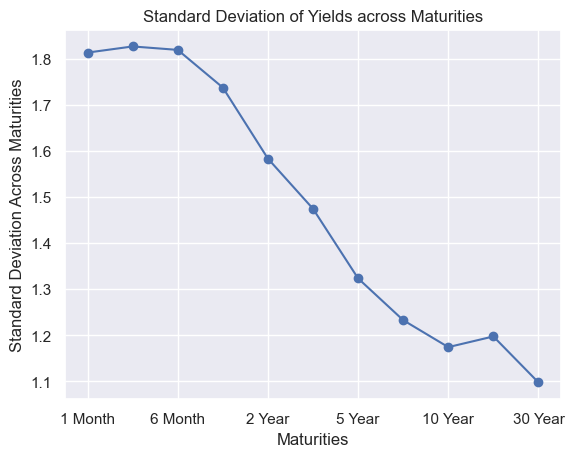

In [16]:
# We Will once also Visualize the standard deviation of yield across various maturities
y_std = yields.std()
y_std.plot(marker='o',title = 'Standard Deviation of Yields across Maturities')
plt.xlabel('Maturities')
plt.ylabel('Standard Deviation Across Maturities')

## Nelson Seigal Model for Yield Curve Fitting

The formula for Nelson Seigal Model is given by 
$$
y(t) = \beta_0 + \beta_1 \left( \frac{1 - e^{-\lambda t}}{\lambda t} \right) + \beta_2 \left( \frac{1 - e^{-\lambda t}}{\lambda t} - e^{-\lambda t} \right) + \varepsilon
$$

* Here $\beta_0$ is Long Term Average of Yield Curve
* $\beta_1$ is Slope of Yield curve or Steepness of Yeild Curve when it starts
* $\beta_2$ is the Curvature or lump in the Yield Curve
* $\lambda$ is the Decay factor which Tells us how quickly the curvature dissapears as we move along the curve

In [80]:
#We Will First Calibrate the yield curve data for the latest date we have and then we will try to do it for different dates
Latest_date = yields.loc['2025-06-09']
Latest_date_yields = pd.DataFrame(Latest_date)
Latest_date_yields

,2025-06-09
1 Month,4.29
3 Month,4.44
6 Month,4.32
1 Year,4.13
2 Year,4.01
3 Year,3.99
5 Year,4.09
7 Year,4.28
10 Year,4.49
20 Year,4.98


In [81]:
from pandas import Timestamp
#Adding Maturity column and converting Months to Years
Latest_date_yields['Maturity'] = [0.0833,0.25,0.5,1,2,3,5,7,10,20,30]

#Dropping the current index
Latest_date_yields = Latest_date_yields.reset_index(drop=True)

#Renaming the yield index
Latest_date_yields= Latest_date_yields.rename(columns={Timestamp('2025-06-09'): 'Yields'})
#Swapping the Yields and Maturity Index
Latest_date_yields


,Yields,Maturity
0,4.29,0.0833
1,4.44,0.2500
2,4.32,0.5000
3,4.13,1.0000
4,4.01,2.0000
5,3.99,3.0000
6,4.09,5.0000
7,4.28,7.0000
8,4.49,10.0000
9,4.98,20.0000


In [82]:
# We Will now Write a loss minimizing function that will minimize the difference between market yield and model yield and help us to get Market Calibrated Parameters
#instead of using loop we will use vectorized version for faster codes
def vec_minimizing_func(params,data):
    B_0 = params[0]
    B_1 = params[1]
    B_2 = params[2]
    lamb = params[3]

    #Creates a list of maturities
    t = data['Maturity']

    #Creates a list of observed rates
    y_obs = data['Yields']

    #creates a list of factor1 factor2 and y_model
    factor_1 = (1 - np.exp(-lamb*t)) / (lamb*t)
    factor_2 = factor_1 - np.exp(-lamb*t)
    y_model = B_0 + (B_1 * factor_1) + (B_2 * factor_2)
    y_model = np.round(y_model,2)
    

    MSE = np.mean((y_model - y_obs)**2)

    return MSE

We Optimized using differential Evolution which is an optimization technique that helps us to find the best parameters. In this we first start with some no. of random samples, let's say X1,X2,X3 where X1 = [param1,param2,param3,param4], X2 and X3 are on similar lines. Let's list the steps/order of algo:- 
1) Start with random or stochastic sets of values like X1,X2,X3
2) We compute MSE using all these 3 different set of values 
3) The algorithm then picks up a new guess based on existing guess by using the equation V = X1 + F(X2-X3), where F is a scaling factor between 0.4 and 1. The new V generated will be also of 4 elements. We will now compare MSE of V with lowest of X1,X2 and X3. 
4) If V has lower MSE we keep it and remove the worst performing X (Suppose it was X1), we now have V, X2, X3. We will use this new set to create new V's
5) If V does not have lower MSE we use some different F to get a new V
6) We stop once we stop getting better rmse values. 

In [83]:
from scipy.optimize import differential_evolution

#We will define the bounds for our Parameters below
bounds = [(0, 10), (-10, 10), (-10, 10), (0.001, 20)]

#differential Evolution works like it takes the minimizing function first, then list of bounds of our 4 parameters and then any other remaining arguement
results = differential_evolution(vec_minimizing_func,bounds,args = (Latest_date_yields,)) 
params_updated = results['x']
params_updated

array([ 5.32518189, -0.87792372, -2.89727576,  0.42991901])

In [84]:
def model_yield(params,data):
    B_0 = params[0]
    B_1 = params[1]
    B_2 = params[2]
    lamb = params[3]
    
    model_yield = []

    for _, row in data.iterrows():
        t = row['Maturity']
        factor_1 = (1 - np.exp(-lamb*t)) / (lamb*t)
        factor_2 = factor_1 - np.exp(-lamb*t)
        calculated_yield = B_0 + (B_1 * factor_1) + (B_2 * factor_2)
        model_yield.append(calculated_yield)
    
    return model_yield


In [86]:
Latest_date_yields['Model_Yield'] = np.round(model_yield(params_updated,Latest_date_yields),2)
Latest_date_yields

,Yields,Maturity,Model_Yield
0,4.29,0.0833,4.41
1,4.44,0.2500,4.35
2,4.32,0.5000,4.27
3,4.13,1.0000,4.14
4,4.01,2.0000,4.02
5,3.99,3.0000,4.00
6,4.09,5.0000,4.11
7,4.28,7.0000,4.28
8,4.49,10.0000,4.50
9,4.98,20.0000,4.89


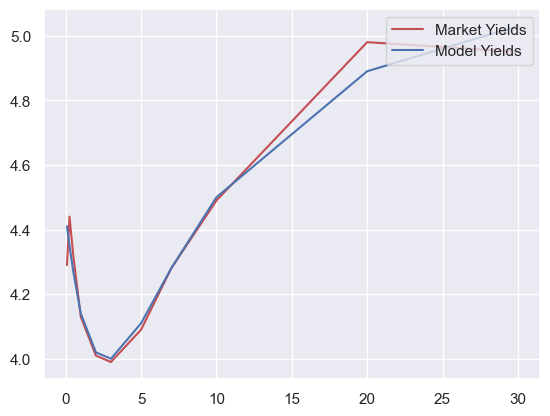

In [87]:
plt.plot(Latest_date_yields['Maturity'],Latest_date_yields['Yields'],color = 'r', label = 'Market Yields')
plt.plot(Latest_date_yields['Maturity'],Latest_date_yields['Model_Yield'],color = 'b', label = 'Model Yields')
plt.legend(loc = 'upper right')
plt.show()

Here We can see for shorter Maturities out Model is correctly interpreting the Yield curve but it is not being able to correctly calibrate the yield curve for longer maturities. This is mostly because Lambda is not being able to capture the Hump Properly

In [88]:
market_yields = np.array(Latest_date_yields['Yields'])
model_yields = np.array(Latest_date_yields['Model_Yield'])

MSE = np.average((model_yields-market_yields)**2)
print(MSE)

0.003663636363636398


MSE for our Model is quite Low

### DataSet 2 

We will use the slope of date which has complex yield structure to see how our Model performs when Yield structure is not simply upward Slopping

In [90]:
#Let us try for some other date 
old_date = yields.loc['2006-03-23']
old_date_yields = pd.DataFrame(old_date)

#Adding Maturity column and converting Months to Years
old_date_yields['Maturity'] = [0.0833,0.25,0.5,1,2,3,5,7,10,20,30]

#Dropping the current index
old_date_yields = old_date_yields.reset_index(drop=True)

#Renaming the yield index
old_date_yields= old_date_yields.rename(columns={Timestamp('2006-03-23'): 'Yields'})
#Swapping the Yields and Maturity Index
old_date_yields

,Yields,Maturity
0,4.66,0.0833
1,4.67,0.2500
2,4.81,0.5000
3,4.80,1.0000
4,4.77,2.0000
5,4.74,3.0000
6,4.73,5.0000
7,4.73,7.0000
8,4.73,10.0000
9,4.93,20.0000


In [91]:
#We will define the bounds for our Parameters below
bounds = [(0, 10), (-10, 10), (-10, 10), (0.001, 10)]

#differential Evolution works like it takes the minimizing function first, then list of bounds of our 4 parameters and then any other remaining arguement
results = differential_evolution(vec_minimizing_func,bounds,args = (old_date_yields,)) 
params_updated = results['x']
params_updated

array([ 4.77532217, -0.18302857,  0.15456592,  5.66138247])

In [92]:
old_date_yields['Model_Yield'] = np.round(model_yield(params_updated,old_date_yields),2)
old_date_yields

,Yields,Maturity,Model_Yield
0,4.66,0.0833,4.66
1,4.67,0.2500,4.72
2,4.81,0.5000,4.76
3,4.80,1.0000,4.77
4,4.77,2.0000,4.77
5,4.74,3.0000,4.77
6,4.73,5.0000,4.77
7,4.73,7.0000,4.77
8,4.73,10.0000,4.77
9,4.93,20.0000,4.78


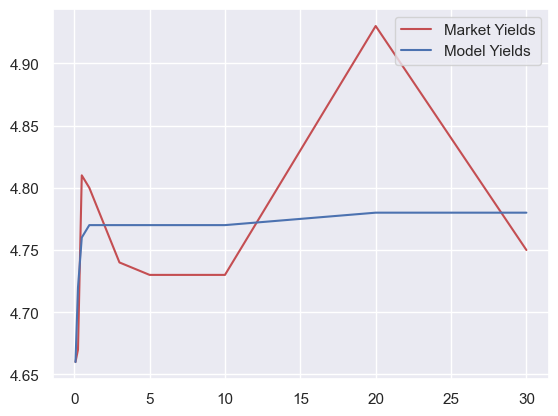

In [93]:
plt.plot(old_date_yields['Maturity'],old_date_yields['Yields'],color = 'r', label = 'Market Yields')
plt.plot(old_date_yields['Maturity'],old_date_yields['Model_Yield'],color = 'b', label = 'Model Yields')
plt.legend(loc = 'upper right')
plt.show()

From This we can observe that NS model can fit curves that are : 
1) Upward Slopping
2) Downward Slopping
3) With a Single Hump 

But NS fails when the curve has : 
1) More than 1 humps or curvature
2) Is not monotonic with complex curvature
3) Has sharp peaks and Drops 

We can Try NSS model in future which can be extended to more than 1 hump, We will also try Cubic Spline Interpolation Below


## Cubic Spline Interpolation For Yield Curve Data

We will now see how Cubic Spline Interpolation might be used to get Yield Data, cubic spline can be used to fit non linear data points and it is non parameteric method as well, however it does not have have any economic interpretation as NS model 

Cubic Spline method involves finding the curve between two datapoints, for eg if we have 4 points we will have 12 variables. We will get 6 equations by putting the 4 points (2 inner and 2 outer) in the equations, we will get 2 more equations by comparing the derivative at inner points, similarly we will get 2 more equations by comparing 2nd degree derivative at inner points. For last two equations you can double derivative at both the ends to be 0. The theory is properly covered in WQU notes of financial Data

In [98]:
from scipy.interpolate import CubicSpline

In [105]:
maturities = np.array(old_date_yields['Maturity'])
yields = np.array(old_date_yields['Yields'])

In [106]:
maturities

array([ 0.0833,  0.25  ,  0.5   ,  1.    ,  2.    ,  3.    ,  5.    ,
        7.    , 10.    , 20.    , 30.    ])

In [107]:
yields

array([4.66, 4.67, 4.81, 4.8 , 4.77, 4.74, 4.73, 4.73, 4.73, 4.93, 4.75])

In [108]:
#Fitting the cubic spline 
cs = CubicSpline(maturities,yields)

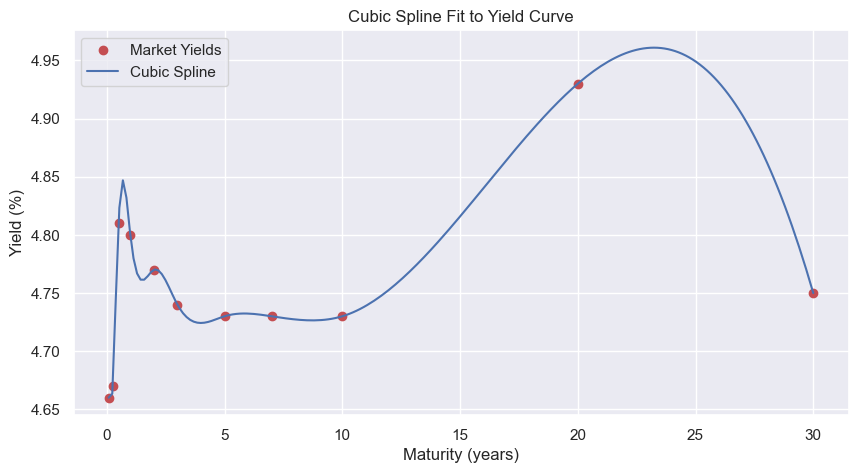

In [109]:
# Generate smooth curve points
maturities_fine = np.linspace(maturities.min(), maturities.max(), 200)
yields_fitted = cs(maturities_fine)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(maturities, yields, 'ro', label='Market Yields')            # actual points
plt.plot(maturities_fine, yields_fitted, 'b-', label='Cubic Spline') # smooth spline
plt.xlabel("Maturity (years)")
plt.ylabel("Yield (%)")
plt.title("Cubic Spline Fit to Yield Curve")
plt.legend()
plt.grid(True)
plt.show()

Here we Can see that our complex curve was fit properly using non parametric method of Cubic Spline